In [1]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# run once to get 64 x 64 imgs
# images = np.load("kanji_images.npy", mmap_mode="r")
# resized = np.empty((len(images), 64, 64), dtype=np.uint8)

# for i in range(len(images)):
#     img = Image.fromarray(images[i]).resize((64, 64), Image.BILINEAR)
#     resized[i] = np.array(img)

# np.save("kanji_images_64.npy", resized)

In [4]:
from torch.utils.data import Dataset, DataLoader

# batch & normalizing

class KanjiDataset(Dataset):
    def __init__(self, image_file, label_file, indices):
        self.images = np.load(image_file)
        self.labels = np.load(label_file)
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image = torch.from_numpy(self.images[real_idx].copy()).float().div(255.0).unsqueeze(0)
        label = torch.tensor(self.labels[real_idx]).long()

        return image, label

In [5]:
from sklearn.model_selection import train_test_split

# train test split
class_list = np.load("class_list.npy")
y = np.load("kanji_labels.npy")

indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=42)

train_data = KanjiDataset("kanji_images_64.npy", "kanji_labels.npy", train_idx)
val_data = KanjiDataset("kanji_images_64.npy", "kanji_labels.npy", val_idx)
test_data = KanjiDataset( "kanji_images_64.npy", "kanji_labels.npy", test_idx)

In [6]:
# image, label = train_data[0]
# print(image.size())
# print(len(class_list))

In [7]:
# define CNN network
class NeuralNet(nn.Module):

    # blocks = 3x3 conv, 

    def __init__(self, num_classes=3036, input_size=64):
        super().__init__()

        self.features = nn.Sequential(
            # block 1
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # infer flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            flat_size = self.features(dummy).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )


    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [8]:
# loop for hyperparameter tuning
def train_model(lr, batch_size, epochs=10, weight_decay=0.0, use_scheduler=True):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    net = NeuralNet().to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2) if use_scheduler else None

    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []} # store training history

    for epoch in range(epochs):
        net.train()
        print(f'Training epoch {epoch}...')
        running_loss = 0.0
    
        for inputs, labels in train_loader:
    
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
    
            optimizer.zero_grad()
    
            outputs = net(inputs)
    
            loss = loss_function(outputs, labels)
            loss.backward() # backward propagation
            optimizer.step()
    
            running_loss += loss.item()
    
        history['train_loss'].append(running_loss / len(train_loader))
    
        print(f'Loss: {running_loss / len(train_loader):.4f}')
    
        # validation
        net.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = net(inputs)
                loss = loss_function(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
    
        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(100 * val_correct / val_total)
    
        print(f'Val Loss: {val_loss/len(val_loader):.4f}, Val Accuracy: {100*val_correct/val_total:.2f}%')

        if scheduler:
            scheduler.step(avg_val_loss)

    return net, history

In [ ]:
import time

results = {}

settings = [
    {'lr': 0.001, 'batch_size': 128, 'epochs': 15, 'weight_decay': 0.0, 'use_scheduler': True},
    {'lr': 0.002, 'batch_size': 128, 'epochs': 15, 'weight_decay': 0.0, 'use_scheduler': True},
    {'lr': 0.001, 'batch_size': 256, 'epochs': 15, 'weight_decay': 0.0, 'use_scheduler': True},
    {'lr': 0.002, 'batch_size': 256, 'epochs': 15, 'weight_decay': 0.0, 'use_scheduler': True},
    {'lr': 0.003, 'batch_size': 256, 'epochs': 15, 'weight_decay': 0.0, 'use_scheduler': True},
]

best_val_acc = 0
best_model_state = None

for i, setting in enumerate(settings):
    name = f"cfg{i}: lr={setting['lr']}, bs={setting['batch_size']}, wd={setting['weight_decay']}"
    print(f"Training with settings: {name}")

    start = time.time()
    net, history = train_model(**setting)
    elapsed = time.time() - start

    history['train_time'] = elapsed
    results[name] = history
    print(f"Training completed in {elapsed/60:.2f} min.")

    config_best_acc = max(history['val_accuracy'])
    if config_best_acc > best_val_acc:
        best_val_acc = config_best_acc
        best_model_state = net.state_dict()
        print(f"  New best overall: {best_val_acc:.2f}% ({name})")

torch.save(best_model_state, 'kanji_model.pth')

Training with settings: cfg0: lr=0.001, bs=128, wd=0.0
Training epoch 0...
Loss: 7.9968
Val Loss: 7.8041, Val Accuracy: 0.35%
Training epoch 1...
Loss: 5.6743
Val Loss: 1.9070, Val Accuracy: 69.49%
Training epoch 2...
Loss: 1.3133
Val Loss: 1.9134, Val Accuracy: 56.60%
Training epoch 3...
Loss: 0.4642
Val Loss: 0.1661, Val Accuracy: 96.15%
Training epoch 4...
Loss: 0.2704
Val Loss: 0.1141, Val Accuracy: 97.37%
Training epoch 5...
Loss: 0.1877
Val Loss: 0.1100, Val Accuracy: 97.61%
Training epoch 6...


KeyboardInterrupt: 

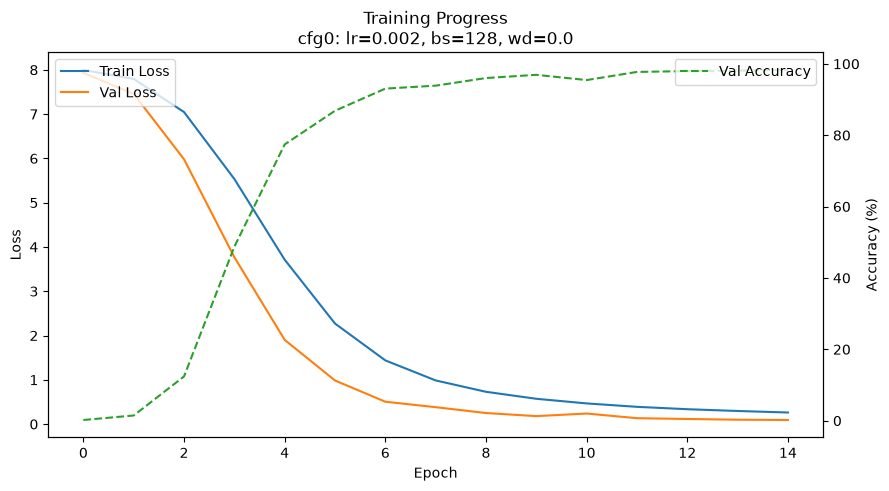

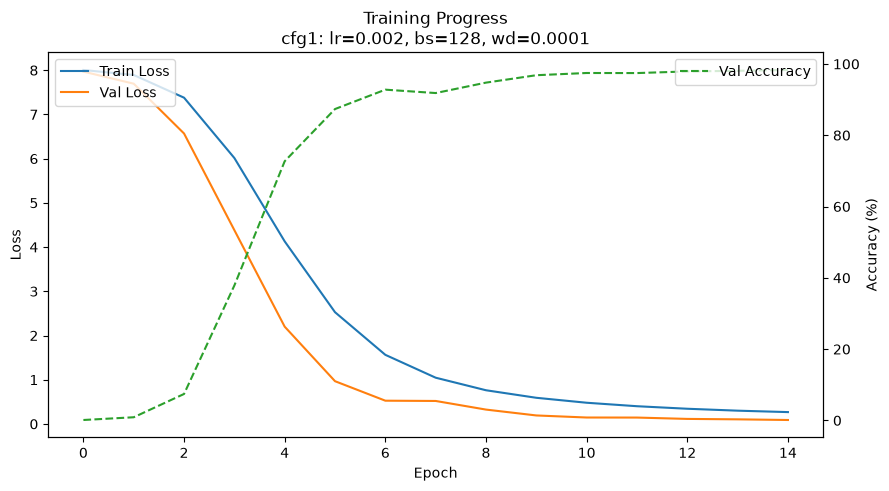

In [ ]:
# plot
import matplotlib.pyplot as plt

for setting, history in results.items():
    train_losses = history['train_loss']
    val_losses = history['val_loss']
    val_accuracies = history['val_accuracy']

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(train_losses, label='Train Loss', color='tab:blue')
    ax1.plot(val_losses, label='Val Loss', color='tab:orange')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(val_accuracies, label='Val Accuracy', color='tab:green', linestyle='--')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend(loc='upper right')

    plt.title(f'Training Progress\n{setting}')
    plt.show()

In [ ]:
net = NeuralNet().to(device)
net.load_state_dict(torch.load('kanji_model.pth', map_location=device))

In [ ]:
# eval on test data
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
correct = 0
total = 0

net.eval()

# feed data in to get predictions and compare to labels
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f'Accuracy: {accuracy}%')